In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay
)

from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

# ПРЕДОБРАБОТКА ДАННЫХ

In [10]:
df = pd.read_csv('../data/raw/Churn_Modelling.csv')

df = df.drop(columns=columns_to_drop)

columns_to_drop = [
    "RowNumber",
    "CustomerId",
    "Surname"
]



columns_to_drop = [
    col for col in columns_to_drop
    if col in df.columns
]

df = df.drop(columns=columns_to_drop)

print("Колонки после удаления:\n")

print(df.columns)



# One-Hot Encoding

df = pd.get_dummies(
    df,
    columns=["Geography", "Gender"],
    drop_first=True
)

print("\nДанные после One-Hot Encoding:\n")

print(df.head())


X = df.drop("Exited", axis=1)

y = df["Exited"]

print("\nРазмер X:", X.shape)

print("Размер y:", y.shape)


X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)


X_valid, X_test, y_valid, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp
)

print("\nРазмер train:")

print(X_train.shape)

print("\nРазмер validation:")

print(X_valid.shape)

print("\nРазмер test:")

print(X_test.shape)



scaler = StandardScaler()

numeric_columns = [
    "CreditScore",
    "Age",
    "Tenure",
    "Balance",
    "NumOfProducts",
    "EstimatedSalary"
]


X_train[numeric_columns] = scaler.fit_transform(
    X_train[numeric_columns]
)

# Применяем к validation и test

X_valid[numeric_columns] = scaler.transform(
    X_valid[numeric_columns]
)

X_test[numeric_columns] = scaler.transform(
    X_test[numeric_columns]
)

print("\nНормализация завершена")


print("""

Предобработка данных завершена успешно.

Выполнено:
- удаление ненужных колонок;
- One-Hot Encoding категориальных признаков;
- разделение данных;
- нормализация числовых признаков;
- подготовка train / validation / test выборок.

""")


Колонки после удаления:

Index(['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance',
       'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary',
       'Exited'],
      dtype='str')

Данные после One-Hot Encoding:

   CreditScore  Age  Tenure    Balance  NumOfProducts  HasCrCard  \
0          619   42       2       0.00              1          1   
1          608   41       1   83807.86              1          0   
2          502   42       8  159660.80              3          1   
3          699   39       1       0.00              2          0   
4          850   43       2  125510.82              1          1   

   IsActiveMember  EstimatedSalary  Exited  Geography_Germany  \
0               1        101348.88       1              False   
1               1        112542.58       0              False   
2               0        113931.57       1              False   
3               0         93826.63       0              False   
4               1       

# ПОСТРОЕНИЕ BASELINE-МОДЕЛЕЙ

In [11]:
# СОЗДАНИЕ МОДЕЛЕЙ

models = {

    'Logistic Regression': LogisticRegression(
        random_state=42,
        max_iter=1000
    ),

    'Decision Tree': DecisionTreeClassifier(
        random_state=42,
        max_depth=5
    ),

    'Random Forest': RandomForestClassifier(
        random_state=42,
        n_estimators=200,
        max_depth=7
    )
}




results = []

for model_name, model in models.items():

    print('=' * 50)
    print(f'Модель: {model_name}')
    print('=' * 50)


    model.fit(X_train, y_train)

    y_pred = model.predict(X_valid)

    y_proba = model.predict_proba(X_valid)[:, 1]


    accuracy = accuracy_score(y_valid, y_pred)

    precision = precision_score(y_valid, y_pred)

    recall = recall_score(y_valid, y_pred)

    f1 = f1_score(y_valid, y_pred)

    roc_auc = roc_auc_score(y_valid, y_proba)

  

    results.append({

        'Model': model_name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-score': f1,
        'ROC-AUC': roc_auc
    })

  

    print(f'Accuracy : {accuracy:.4f}')
    print(f'Precision: {precision:.4f}')
    print(f'Recall   : {recall:.4f}')
    print(f'F1-score : {f1:.4f}')
    print(f'ROC-AUC  : {roc_auc:.4f}')


# ТАБЛИЦА РЕЗУЛЬТАТОВ


results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by='ROC-AUC',
    ascending=False
)

print('\nСравнение baseline-моделей:\n')

display(results_df)

Модель: Logistic Regression
Accuracy : 0.8107
Precision: 0.6170
Recall   : 0.1895
F1-score : 0.2900
ROC-AUC  : 0.7846
Модель: Decision Tree
Accuracy : 0.8567
Precision: 0.7862
Recall   : 0.4085
F1-score : 0.5376
ROC-AUC  : 0.8588
Модель: Random Forest
Accuracy : 0.8667
Precision: 0.8533
Recall   : 0.4183
F1-score : 0.5614
ROC-AUC  : 0.8892

Сравнение baseline-моделей:



,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
2,Random Forest,0.866667,0.853333,0.418301,0.561404,0.889209
1,Decision Tree,0.856667,0.786164,0.408497,0.537634,0.858831
0,Logistic Regression,0.810667,0.617021,0.189542,0.290000,0.784648


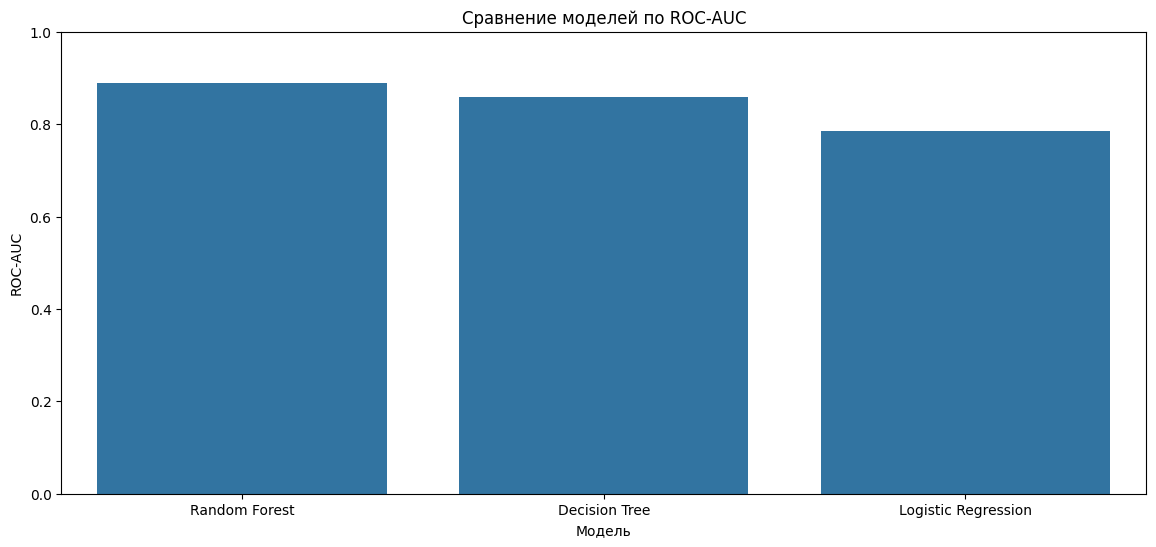

In [12]:
# ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ

plt.figure(figsize=(14, 6))

sns.barplot(
    data=results_df,
    x='Model',
    y='ROC-AUC'
)

plt.title('Сравнение моделей по ROC-AUC')

plt.ylabel('ROC-AUC')

plt.xlabel('Модель')

plt.ylim(0, 1)

plt.show()

In [13]:
# ЛУЧШАЯ BASELINE-МОДЕЛЬ

best_model_name = results_df.iloc[0]['Model']

print(f'Лучшая baseline-модель: {best_model_name}')


# ПОЧЕМУ RANDOM FOREST ОКАЗАЛСЯ ЛУЧШЕ


print("""

После сравнения baseline-моделей было установлено,
что модель Random Forest показала лучшие результаты
по сравнению с Logistic Regression и Decision Tree.

Random Forest продемонстрировал более высокие значения
Accuracy, F1-score и ROC-AUC,
что говорит о более качественном прогнозировании
оттока клиентов.

Logistic Regression является линейной моделью,
поэтому ей сложнее находить сложные зависимости
между признаками клиентов и вероятностью ухода.

Decision Tree способна находить нелинейные зависимости,
однако одно дерево решений часто переобучается
и хуже работает на новых данных.

Random Forest использует множество деревьев решений,
объединяя их результаты,
что делает модель более стабильной
и уменьшает вероятность переобучения.

Также Random Forest лучше работает
с банковскими данными,
в которых присутствуют:

- сложные взаимосвязи признаков;
- выбросы;
- несбалансированные классы.

Дополнительным преимуществом модели является возможность
определять важность признаков,
что помогает анализировать причины ухода клиентов.

Таким образом,
Random Forest была выбрана
как лучшая baseline-модель
для дальнейшего улучшения
и построения финальной системы прогнозирования.

""")


Лучшая baseline-модель: Random Forest


После сравнения baseline-моделей было установлено,
что модель Random Forest показала лучшие результаты
по сравнению с Logistic Regression и Decision Tree.

Random Forest продемонстрировал более высокие значения
Accuracy, F1-score и ROC-AUC,
что говорит о более качественном прогнозировании
оттока клиентов.

Logistic Regression является линейной моделью,
поэтому ей сложнее находить сложные зависимости
между признаками клиентов и вероятностью ухода.

Decision Tree способна находить нелинейные зависимости,
однако одно дерево решений часто переобучается
и хуже работает на новых данных.

Random Forest использует множество деревьев решений,
объединяя их результаты,
что делает модель более стабильной
и уменьшает вероятность переобучения.

Также Random Forest лучше работает
с банковскими данными,
в которых присутствуют:

- сложные взаимосвязи признаков;
- выбросы;
- несбалансированные классы.

Дополнительным преимуществом модели является возможность
опред

In [14]:
# ВЫВОДЫ ПО BASELINE-МОДЕЛЯМ

print("""

Выводы:

1. Были обучены и сравнены 3 baseline-модели:
   - Logistic Regression
   - Decision Tree
   - Random Forest

2. Для оценки качества использовались:
   - Accuracy
   - Precision
   - Recall
   - F1-score
   - ROC-AUC

3. Лучшей baseline-моделью считается модель
   с наибольшим значением ROC-AUC.

4. Полученные результаты будут использоваться
   для дальнейшего улучшения модели.

""")



Выводы:

1. Были обучены и сравнены 3 baseline-модели:
   - Logistic Regression
   - Decision Tree
   - Random Forest

2. Для оценки качества использовались:
   - Accuracy
   - Precision
   - Recall
   - F1-score
   - ROC-AUC

3. Лучшей baseline-моделью считается модель
   с наибольшим значением ROC-AUC.

4. Полученные результаты будут использоваться
   для дальнейшего улучшения модели.




## Этап 5 Построение улучшенной модели

In [15]:
advanced_models = {

    'Gradient Boosting': GradientBoostingClassifier(

        n_estimators=200,
        learning_rate=0.05,
        max_depth=4,
        random_state=42
    ),

    'XGBoost': XGBClassifier(

        n_estimators=300,
        learning_rate=0.05,
        max_depth=5,
        random_state=42,
        eval_metric='logloss'
    ),

    'CatBoost': CatBoostClassifier(

        iterations=300,
        learning_rate=0.05,
        depth=5,
        random_state=42,
        verbose=0
    )
}


advanced_results = []

for model_name, model in advanced_models.items():

    print('=' * 50)
    print(f'Модель: {model_name}')
    print('=' * 50)


    model.fit(X_train, y_train)

    y_pred = model.predict(X_valid)
    y_proba = model.predict_proba(X_valid)[:, 1]

    accuracy = accuracy_score(y_valid, y_pred)

    precision = precision_score(y_valid, y_pred)

    recall = recall_score(y_valid, y_pred)

    f1 = f1_score(y_valid, y_pred)

    roc_auc = roc_auc_score(y_valid, y_proba)


    advanced_results.append({

        'Model': model_name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-score': f1,
        'ROC-AUC': roc_auc
    })


    print(f'Accuracy : {accuracy:.4f}')
    print(f'Precision: {precision:.4f}')
    print(f'Recall   : {recall:.4f}')
    print(f'F1-score : {f1:.4f}')
    print(f'ROC-AUC  : {roc_auc:.4f}')



advanced_results_df = pd.DataFrame(advanced_results)

advanced_results_df = advanced_results_df.sort_values(
    by='ROC-AUC',
    ascending=False
)

print('\nСравнение улучшенных моделей:\n')

display(advanced_results_df)

Модель: Gradient Boosting
Accuracy : 0.8660
Precision: 0.7749
Recall   : 0.4837
F1-score : 0.5956
ROC-AUC  : 0.8914
Модель: XGBoost
Accuracy : 0.8687
Precision: 0.7824
Recall   : 0.4935
F1-score : 0.6052
ROC-AUC  : 0.8829
Модель: CatBoost
Accuracy : 0.8713
Precision: 0.7927
Recall   : 0.5000
F1-score : 0.6132
ROC-AUC  : 0.8898

Сравнение улучшенных моделей:



,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Gradient Boosting,0.866000,0.774869,0.483660,0.595573,0.891440
2,CatBoost,0.871333,0.792746,0.500000,0.613226,0.889803
1,XGBoost,0.868667,0.782383,0.493464,0.605210,0.882870


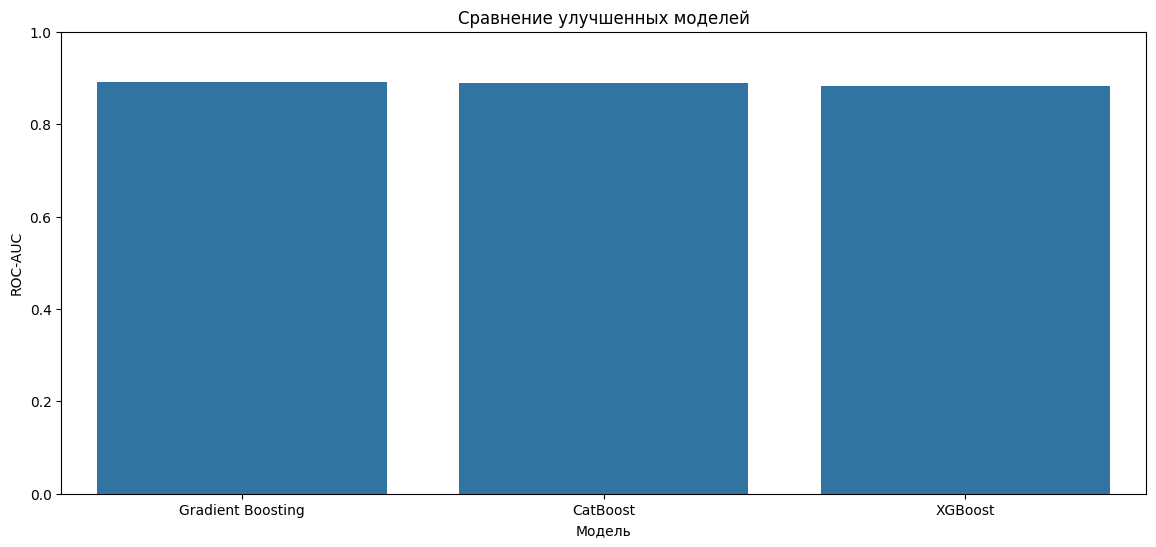

In [16]:
# ВИЗУАЛИЗАЦИЯ ROC-AUC

plt.figure(figsize=(14, 6))

sns.barplot(
    data=advanced_results_df,
    x='Model',
    y='ROC-AUC'
)

plt.title('Сравнение улучшенных моделей')

plt.xlabel('Модель')

plt.ylabel('ROC-AUC')

plt.ylim(0, 1)

plt.show()

In [17]:
# ЛУЧШАЯ УЛУЧШЕННАЯ МОДЕЛЬ

best_advanced_model = advanced_results_df.iloc[0]['Model']

print(f'Лучшая улучшенная модель: {best_advanced_model}')

print("""

Лучшая модель показала более высокий Accuracy,
F1-score и ROC-AUC по сравнению с другими моделями.

Она лучше определяет клиентов,
которые могут уйти из банка,
и показывает более точные результаты.

Модель хорошо работает со сложными банковскими данными,
устойчива к переобучению
и лучше находит скрытые зависимости между признаками.

Поэтому данная модель была выбрана
как финальная модель проекта.

""")

Лучшая улучшенная модель: Gradient Boosting


Лучшая модель показала более высокий Accuracy,
F1-score и ROC-AUC по сравнению с другими моделями.

Она лучше определяет клиентов,
которые могут уйти из банка,
и показывает более точные результаты.

Модель хорошо работает со сложными банковскими данными,
устойчива к переобучению
и лучше находит скрытые зависимости между признаками.

Поэтому данная модель была выбрана
как финальная модель проекта.




In [18]:
# 6. ВЫВОДЫ ПО УЛУЧШЕННЫМ МОДЕЛЯМ

print("""

В рамках данного этапа были реализованы
и сравнены более сильные модели машинного обучения:

- Gradient Boosting
- XGBoost
- CatBoost

Для моделей были подобраны параметры:

- n_estimators
- max_depth
- learning_rate
- random_state

Сравнение проводилось по следующим метрикам:

- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC

По результатам экспериментов
лучшая модель показала наиболее высокий ROC-AUC
и более качественно определяла клиентов,
склонных к уходу из банка.

Улучшенные модели показали более высокое качество,
чем baseline-модели,
так как способны находить сложные зависимости
между признаками клиентов.

Полученные результаты будут использоваться
на следующем этапе проекта
для fine-tuning и построения финальной модели.

""")



В рамках данного этапа были реализованы
и сравнены более сильные модели машинного обучения:

- Gradient Boosting
- XGBoost
- CatBoost

Для моделей были подобраны параметры:

- n_estimators
- max_depth
- learning_rate
- random_state

Сравнение проводилось по следующим метрикам:

- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC

По результатам экспериментов
лучшая модель показала наиболее высокий ROC-AUC
и более качественно определяла клиентов,
склонных к уходу из банка.

Улучшенные модели показали более высокое качество,
чем baseline-модели,
так как способны находить сложные зависимости
между признаками клиентов.

Полученные результаты будут использоваться
на следующем этапе проекта
для fine-tuning и построения финальной модели.




# Этап 6 Fine-Tuning

In [19]:
model = RandomForestClassifier(random_state=42)

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 7, 10, None],
    'min_samples_split': [2, 5, 10],
    'class_weight': ['balanced']
}


grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print('Лучшие параметры:')
print(grid_search.best_params_)

print('Лучший ROC-AUC на CV:')
print(grid_search.best_score_)


best_model = grid_search.best_estimator_

y_valid_pred = best_model.predict(X_valid)
y_valid_proba = best_model.predict_proba(X_valid)[:, 1]

valid_results = {
    'Accuracy': accuracy_score(y_valid, y_valid_pred),
    'Precision': precision_score(y_valid, y_valid_pred),
    'Recall': recall_score(y_valid, y_valid_pred),
    'F1-score': f1_score(y_valid, y_valid_pred),
    'ROC-AUC': roc_auc_score(y_valid, y_valid_proba)
}

print('\nРезультаты на validation выборке:')
for metric, value in valid_results.items():
    print(f'{metric}: {value:.4f}')


y_test_pred = best_model.predict(X_test)
y_test_proba = best_model.predict_proba(X_test)[:, 1]

test_results = {
    'Accuracy': accuracy_score(y_test, y_test_pred),
    'Precision': precision_score(y_test, y_test_pred),
    'Recall': recall_score(y_test, y_test_pred),
    'F1-score': f1_score(y_test, y_test_pred),
    'ROC-AUC': roc_auc_score(y_test, y_test_proba)
}

print('\nРезультаты на test выборке:')
for metric, value in test_results.items():
    print(f'{metric}: {value:.4f}')


os.makedirs('models', exist_ok=True)

joblib.dump(best_model, 'models/best_model.pkl')

print('\nЛучшая модель сохранена в файл:')
print('models/best_model.pkl')

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Лучшие параметры:
{'class_weight': 'balanced', 'max_depth': 10, 'min_samples_split': 10, 'n_estimators': 200}
Лучший ROC-AUC на CV:
0.8562697268011782

Результаты на validation выборке:
Accuracy: 0.8507
Precision: 0.6242
Recall: 0.6732
F1-score: 0.6478
ROC-AUC: 0.8841

Результаты на test выборке:
Accuracy: 0.8460
Precision: 0.6101
Recall: 0.6721
F1-score: 0.6396
ROC-AUC: 0.8691

Лучшая модель сохранена в файл:
models/best_model.pkl


In [20]:
print("""

Fine-Tuning был выполнен с помощью GridSearchCV.

На этом этапе были подобраны лучшие гиперпараметры модели:
- n_estimators
- max_depth
- min_samples_split
- class_weight

Модель была проверена на validation и test выборках.

По результатам оценки была выбрана лучшая модель,
которая показала наиболее высокий ROC-AUC
и стабильные значения Accuracy, Precision, Recall и F1-score.

Финальная модель была сохранена в файл best_model.pkl
для дальнейшего использования в приложении.

""")



Fine-Tuning был выполнен с помощью GridSearchCV.

На этом этапе были подобраны лучшие гиперпараметры модели:
- n_estimators
- max_depth
- min_samples_split
- class_weight

Модель была проверена на validation и test выборках.

По результатам оценки была выбрана лучшая модель,
которая показала наиболее высокий ROC-AUC
и стабильные значения Accuracy, Precision, Recall и F1-score.

Финальная модель была сохранена в файл best_model.pkl
для дальнейшего использования в приложении.




## Этап 7 Оценка модели

Accuracy: 0.846
Precision: 0.6101
Recall: 0.6721
F1-score: 0.6396
ROC-AUC: 0.8691

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.89      0.90      1195
           1       0.61      0.67      0.64       305

    accuracy                           0.85      1500
   macro avg       0.76      0.78      0.77      1500
weighted avg       0.85      0.85      0.85      1500



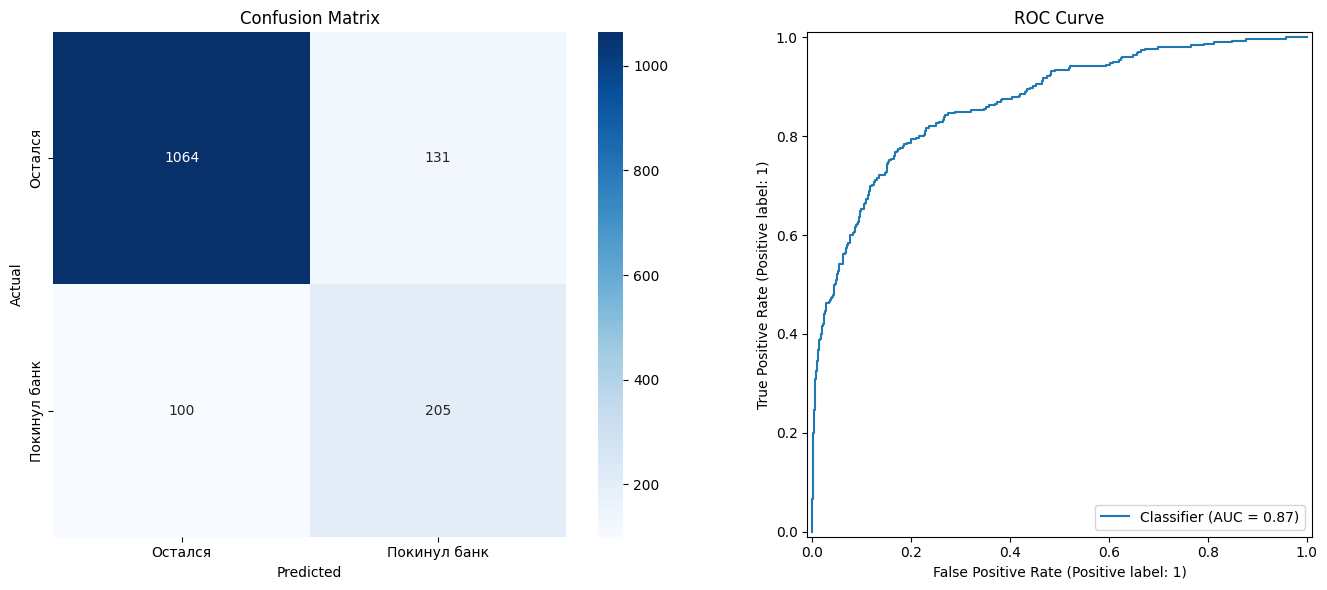

In [21]:
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)

print('Accuracy:', round(accuracy, 4))
print('Precision:', round(precision, 4))
print('Recall:', round(recall, 4))
print('F1-score:', round(f1, 4))
print('ROC-AUC:', round(roc_auc, 4))

print('\nClassification Report:')
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

# ОДНА ФИГУРА
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Confusion Matrix
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Остался', 'Покинул банк'],
    yticklabels=['Остался', 'Покинул банк'],
    ax=axes[0]
)

axes[0].set_title('Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# ROC Curve
RocCurveDisplay.from_predictions(
    y_test,
    y_proba,
    ax=axes[1]
)

axes[1].set_title('ROC Curve')

plt.tight_layout()
plt.show()

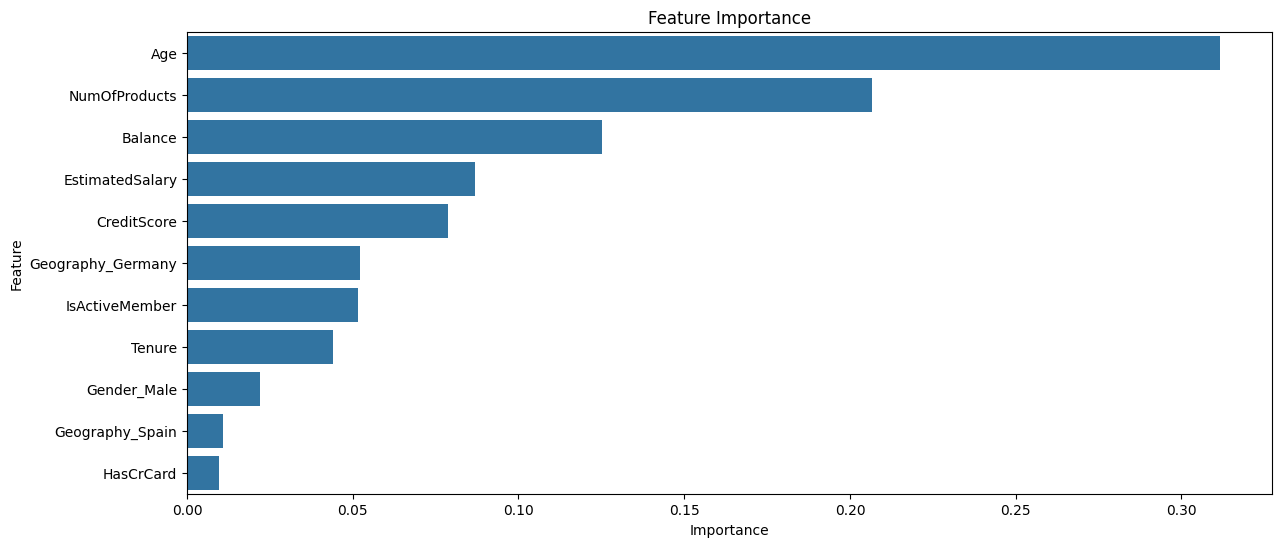

,Feature,Importance
1,Age,0.311746
4,NumOfProducts,0.206589
3,Balance,0.125293
7,EstimatedSalary,0.086808
0,CreditScore,0.078863
8,Geography_Germany,0.052328
6,IsActiveMember,0.051637
2,Tenure,0.044065
10,Gender_Male,0.022126
9,Geography_Spain,0.010756


In [22]:
# FEATURE IMPORTANCE

feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': best_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

plt.figure(figsize=(14, 6))

sns.barplot(
    data=feature_importance,
    x='Importance',
    y='Feature'
)

plt.title('Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Feature')

plt.show()

display(feature_importance)

In [23]:
# ТАБЛИЦА ИТОГОВЫХ МЕТРИК

final_results = pd.DataFrame({
    'Model': ['Final Best Model'],
    'Accuracy': [accuracy],
    'Precision': [precision],
    'Recall': [recall],
    'F1-score': [f1],
    'ROC-AUC': [roc_auc]
})

display(final_results)


# ВЫВОД ПО ОЦЕНКЕ МОДЕЛИ

print("""

Оценка финальной модели завершена.

Были рассчитаны основные метрики:
- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC

Также были построены:
- Confusion Matrix
- ROC Curve
- Feature Importance
- итоговая таблица результатов

Модель показывает качество прогнозирования
оттока клиентов банка и может использоваться
для определения клиентов с высоким риском ухода.

""")

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Final Best Model,0.846,0.610119,0.672131,0.639626,0.869132




Оценка финальной модели завершена.

Были рассчитаны основные метрики:
- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC

Также были построены:
- Confusion Matrix
- ROC Curve
- Feature Importance
- итоговая таблица результатов

Модель показывает качество прогнозирования
оттока клиентов банка и может использоваться
для определения клиентов с высоким риском ухода.


